# Data Preprocessing 

In [38]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import title, xlabel, ylabel

In [39]:
df=pd.read_excel("churn.xlsx")
df

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39
0,KS,128.0,415.0,382-4657,no,yes,25.0,265.1,110.0,45.07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OH,107.0,415.0,371-7191,no,yes,26.0,161.6,123.0,27.47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NJ,137.0,415.0,358-1921,no,no,0.0,243.4,114.0,41.38,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,OH,84.0,408.0,375-9999,yes,no,0.0,299.4,71.0,50.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,OK,75.0,415.0,330-6626,yes,no,0.0,166.7,113.0,28.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3323,AZ,192.0,415.0,414-4276,no,yes,36.0,156.2,77.0,26.55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3324,WV,68.0,415.0,370-3271,no,no,0.0,231.1,57.0,39.29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3325,RI,28.0,510.0,328-8230,no,no,0.0,180.8,109.0,30.74,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3326,CT,184.0,510.0,364-6381,yes,no,0.0,213.8,105.0,36.35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# Remove unnamed columns
unnamed_columns = [col for col in df.columns if 'Unnamed:' in col]
df = df.drop(columns=unnamed_columns)

print("\nDataFrame with unnamed columns removed:")
df


DataFrame with unnamed columns removed:


,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128.0,415.0,382-4657,no,yes,25.0,265.1,110.0,45.07,...,99,16.78,244.7,91,11.01,10.0,3.0,2.70,1,False.
1,OH,107.0,415.0,371-7191,no,yes,26.0,161.6,123.0,27.47,...,103,16.62,254.4,103,11.45,13.7,3.0,3.70,1,False.
2,NJ,137.0,415.0,358-1921,no,no,0.0,243.4,114.0,41.38,...,110,10.30,162.6,104,7.32,12.2,5.0,3.29,0,False.
3,OH,84.0,408.0,375-9999,yes,no,0.0,299.4,71.0,50.9,...,88,5.26,196.9,89,8.86,6.6,7.0,1.78,2,False.
4,OK,75.0,415.0,330-6626,yes,no,0.0,166.7,113.0,28.34,...,122,12.61,186.9,121,8.41,10.1,3.0,2.73,3,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3323,AZ,192.0,415.0,414-4276,no,yes,36.0,156.2,77.0,26.55,...,126,18.32,279.1,83,12.56,9.9,6.0,2.67,2,False.
3324,WV,68.0,415.0,370-3271,no,no,0.0,231.1,57.0,39.29,...,55,13.04,191.3,123,8.61,9.6,4.0,2.59,3,False.
3325,RI,28.0,510.0,328-8230,no,no,0.0,180.8,109.0,30.74,...,58,24.55,191.9,91,8.64,14.1,6.0,3.81,2,False.
3326,CT,184.0,510.0,364-6381,yes,no,0.0,213.8,105.0,36.35,...,84,13.57,139.2,137,6.26,5.0,10.0,1.35,2,False.


In [41]:
# # Check if any row has more values than the number of columns
# rows_to_remove = []
# for index, row in df.iterrows():
#     if len(row) > len(df.columns):
#         rows_to_remove.append(index)

# # Remove rows with more values than the number of columns
# df = df.drop(rows_to_remove)
# print(df)

In [42]:
x= df.iloc[:, :20].values #Extracting independent variables
y= df.iloc[:,20].values #Extracting Dependent variable  

In [43]:
# Identifying Outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outlier_values = {}
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    lower_bound = Q1[col] - 1.5 * IQR[col]
    upper_bound = Q3[col] + 1.5 * IQR[col]
    outliers = df[col][(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_values[col] = outliers.tolist()

for col, values in outlier_values.items():
    print(f"Outliers in '{col}': {values}")

Outliers in 'Account Length': [208.0, 215.0, 209.0, 224.0, 243.0, 217.0, 210.0, 212.0, 232.0, 225.0, 224.0, 225.0, 224.0, 212.0, 210.0, 217.0, 209.0, 221.0, 209.0]
Outliers in 'Area Code': [102.0]
Outliers in 'VMail Message': [48.0, 48.0, 51.0, 49.0, 50.0, 50.0]
Outliers in 'Day Mins': [332.9, 337.4, 326.5, 350.8, 335.5, 30.9, 34.0, 334.3, 346.8, 12.5, 25.9, 0.0, 0.0, 19.5, 329.8, 7.9, 328.1, 27.0, 17.6, 326.3, 345.3, 2.6, 7.8, 18.9, 29.9]
Outliers in 'Day Calls': [158.0, 163.0, 36.0, 40.0, 158.0, 165.0, 30.0, 42.0, 0.0, 45.0, 0.0, 45.0, 160.0, 156.0, 35.0, 42.0, 158.0, 157.0, 45.0, 44.0, 44.0, 44.0, 40.0]
Outliers in 'Eve Charge': [5.26, 29.62, 29.89, 2.65, 29.79, 3.59, 29.52, 5.01, 3.73, 4.5, 3.61, 5.17, 4.98, 4.76, 4.09, 5.1, 29.83, 191.4, 2.59, 226.7, 4.18, 28.89, 30.75, 30.11, 30.91, 0.0, 29.01]
Outliers in 'Night Mins': [57.5, 354.9, 349.2, 345.8, 45.0, 342.8, 364.3, 63.3, 54.5, 50.1, 43.7, 349.7, 352.5, 23.2, 63.6, 381.9, 377.5, 0.0, 367.7, 56.6, 54.0, 64.2, 344.3, 395.0, 350.2,

In [44]:
# Removing missing values 
columns_to_clean = ['State','Account Length','Area Code','Phone',"Int'l Plan",'VMail Plan','VMail Message','Day Mins','Day Calls','Day Charge','Eve Mins','Eve Calls','Eve Charge','Night Mins','Night Calls','Night Charge','Intl Mins','Intl Calls','Intl Charge','CustServ Calls','Churn?']

df = df.dropna(subset=columns_to_clean)

print("\nDataFrame with missing values removed from specific columns:")
df


DataFrame with missing values removed from specific columns:


,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128.0,415.0,382-4657,no,yes,25.0,265.1,110.0,45.07,...,99,16.78,244.7,91,11.01,10.0,3.0,2.70,1,False.
1,OH,107.0,415.0,371-7191,no,yes,26.0,161.6,123.0,27.47,...,103,16.62,254.4,103,11.45,13.7,3.0,3.70,1,False.
2,NJ,137.0,415.0,358-1921,no,no,0.0,243.4,114.0,41.38,...,110,10.30,162.6,104,7.32,12.2,5.0,3.29,0,False.
3,OH,84.0,408.0,375-9999,yes,no,0.0,299.4,71.0,50.9,...,88,5.26,196.9,89,8.86,6.6,7.0,1.78,2,False.
4,OK,75.0,415.0,330-6626,yes,no,0.0,166.7,113.0,28.34,...,122,12.61,186.9,121,8.41,10.1,3.0,2.73,3,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3323,AZ,192.0,415.0,414-4276,no,yes,36.0,156.2,77.0,26.55,...,126,18.32,279.1,83,12.56,9.9,6.0,2.67,2,False.
3324,WV,68.0,415.0,370-3271,no,no,0.0,231.1,57.0,39.29,...,55,13.04,191.3,123,8.61,9.6,4.0,2.59,3,False.
3325,RI,28.0,510.0,328-8230,no,no,0.0,180.8,109.0,30.74,...,58,24.55,191.9,91,8.64,14.1,6.0,3.81,2,False.
3326,CT,184.0,510.0,364-6381,yes,no,0.0,213.8,105.0,36.35,...,84,13.57,139.2,137,6.26,5.0,10.0,1.35,2,False.


In [45]:
# List of numeric columns to clean
numeric_columns_to_clean = ['Day Charge','Eve Mins','Eve Calls','Night Calls','Night Charge','CustServ Calls']

# Iterate over specified numeric columns
for column in numeric_columns_to_clean:
    # Attempt to convert values to numeric, coercing non-numeric values to NaN
    df[column] = pd.to_numeric(df[column], errors='coerce')

# Remove rows with NaN values (non-convertible string values)
df = df.dropna(subset=numeric_columns_to_clean)




# List of string columns to clean
string_columns_to_clean = ["Int'l Plan",'VMail Plan','Churn?']

# Iterate over specified string columns
for column in string_columns_to_clean:
    # Remove rows with numeric values
    df = df[~df[column].apply(lambda x: str(x).isnumeric())]

df

C:\Users\admi\AppData\Local\Temp\ipykernel_17636\1022515522.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = pd.to_numeric(df[column], errors='coerce')


,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128.0,415.0,382-4657,no,yes,25.0,265.1,110.0,45.07,...,99,16.78,244.7,91.0,11.01,10.0,3.0,2.70,1.0,False.
1,OH,107.0,415.0,371-7191,no,yes,26.0,161.6,123.0,27.47,...,103,16.62,254.4,103.0,11.45,13.7,3.0,3.70,1.0,False.
2,NJ,137.0,415.0,358-1921,no,no,0.0,243.4,114.0,41.38,...,110,10.30,162.6,104.0,7.32,12.2,5.0,3.29,0.0,False.
3,OH,84.0,408.0,375-9999,yes,no,0.0,299.4,71.0,50.90,...,88,5.26,196.9,89.0,8.86,6.6,7.0,1.78,2.0,False.
4,OK,75.0,415.0,330-6626,yes,no,0.0,166.7,113.0,28.34,...,122,12.61,186.9,121.0,8.41,10.1,3.0,2.73,3.0,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3323,AZ,192.0,415.0,414-4276,no,yes,36.0,156.2,77.0,26.55,...,126,18.32,279.1,83.0,12.56,9.9,6.0,2.67,2.0,False.
3324,WV,68.0,415.0,370-3271,no,no,0.0,231.1,57.0,39.29,...,55,13.04,191.3,123.0,8.61,9.6,4.0,2.59,3.0,False.
3325,RI,28.0,510.0,328-8230,no,no,0.0,180.8,109.0,30.74,...,58,24.55,191.9,91.0,8.64,14.1,6.0,3.81,2.0,False.
3326,CT,184.0,510.0,364-6381,yes,no,0.0,213.8,105.0,36.35,...,84,13.57,139.2,137.0,6.26,5.0,10.0,1.35,2.0,False.


In [46]:
# Cleaning irrelevant data
df['Churn?'].unique()
df['Churn?']=df['Churn?'].astype(str)
df=df[df['Churn?'].isin(['True.', 'False.'])]

df["Int'l Plan"].unique()
df["Int'l Plan"]=df["Int'l Plan"].astype(str)
df=df[df["Int'l Plan"].isin(['yes','no'])]

df["VMail Plan"].unique()
df["VMail Plan"]=df["Int'l Plan"].astype(str)
df=df[df["VMail Plan"].isin(['yes','no'])]

df

C:\Users\admi\AppData\Local\Temp\ipykernel_17636\2712254608.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Int'l Plan"]=df["Int'l Plan"].astype(str)
C:\Users\admi\AppData\Local\Temp\ipykernel_17636\2712254608.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["VMail Plan"]=df["Int'l Plan"].astype(str)


,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128.0,415.0,382-4657,no,no,25.0,265.1,110.0,45.07,...,99,16.78,244.7,91.0,11.01,10.0,3.0,2.70,1.0,False.
1,OH,107.0,415.0,371-7191,no,no,26.0,161.6,123.0,27.47,...,103,16.62,254.4,103.0,11.45,13.7,3.0,3.70,1.0,False.
2,NJ,137.0,415.0,358-1921,no,no,0.0,243.4,114.0,41.38,...,110,10.30,162.6,104.0,7.32,12.2,5.0,3.29,0.0,False.
3,OH,84.0,408.0,375-9999,yes,yes,0.0,299.4,71.0,50.90,...,88,5.26,196.9,89.0,8.86,6.6,7.0,1.78,2.0,False.
4,OK,75.0,415.0,330-6626,yes,yes,0.0,166.7,113.0,28.34,...,122,12.61,186.9,121.0,8.41,10.1,3.0,2.73,3.0,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3323,AZ,192.0,415.0,414-4276,no,no,36.0,156.2,77.0,26.55,...,126,18.32,279.1,83.0,12.56,9.9,6.0,2.67,2.0,False.
3324,WV,68.0,415.0,370-3271,no,no,0.0,231.1,57.0,39.29,...,55,13.04,191.3,123.0,8.61,9.6,4.0,2.59,3.0,False.
3325,RI,28.0,510.0,328-8230,no,no,0.0,180.8,109.0,30.74,...,58,24.55,191.9,91.0,8.64,14.1,6.0,3.81,2.0,False.
3326,CT,184.0,510.0,364-6381,yes,yes,0.0,213.8,105.0,36.35,...,84,13.57,139.2,137.0,6.26,5.0,10.0,1.35,2.0,False.


In [47]:
# maximum, minimum, mean, standard deviation
df.describe()

,Account Length,Area Code,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
count,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000
mean,101.046427,437.273440,8.095267,179.734127,100.443473,30.555339,200.851251,100.109436,17.072566,200.800784,100.112150,9.036117,10.242599,4.482665,2.766011,1.564667
std,39.833182,42.420574,13.689869,54.437380,20.086759,9.254331,50.711416,19.922749,4.310460,50.500897,19.549065,2.272590,2.789795,2.462766,0.753227,1.315375
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.400000,87.000000,14.140000,167.100000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.100000,100.000000,17.090000,201.100000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.200000,114.000000,36.750000,235.200000,114.000000,19.990000,235.200000,113.000000,10.580000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


Text(0.5, 1.0, 'Histogram of Account Length')

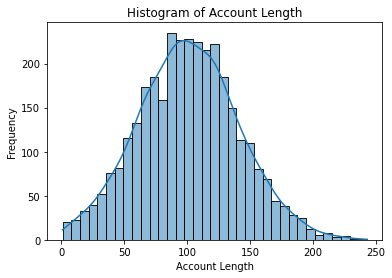

In [48]:
sns.histplot(data=df['Account Length'],kde=True)
plt.xlabel("Account Length")
plt.ylabel('Frequency')
title("Histogram of Account Length")

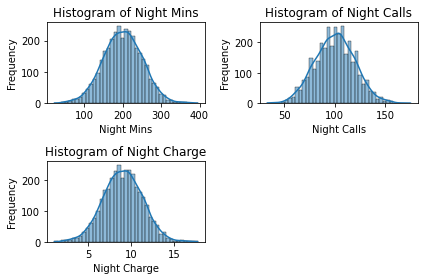

In [49]:
plt.subplot(2,2,1)
sns.histplot(data=df['Night Mins'],kde=True)
plt.xlabel("Night Mins")
plt.ylabel('Frequency')
title("Histogram of Night Mins")

plt.subplot(2,2,2)
sns.histplot(data=df['Night Calls'],kde=True)
plt.xlabel("Night Calls")
plt.ylabel('Frequency')
title("Histogram of Night Calls")

plt.subplot(2,2,3)
sns.histplot(data=df['Night Charge'],kde=True)
plt.xlabel("Night Charge")
plt.ylabel('Frequency')
title("Histogram of Night Charge")

plt.tight_layout()

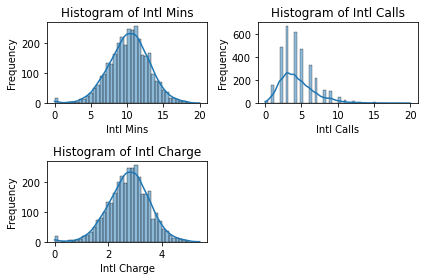

In [50]:
plt.subplot(2,2,1)
sns.histplot(data=df['Intl Mins'],kde=True)
plt.xlabel("Intl Mins")
plt.ylabel('Frequency')
title("Histogram of Intl Mins")

plt.subplot(2,2,2)
sns.histplot(data=df['Intl Calls'],kde=True)
plt.xlabel("Intl Calls")
plt.ylabel('Frequency')
title("Histogram of Intl Calls")

plt.subplot(2,2,3)
sns.histplot(data=df['Intl Charge'],kde=True)
plt.xlabel("Intl Charge")
plt.ylabel('Frequency')
title("Histogram of Intl Charge")

plt.tight_layout()

In [51]:
#Distribution
class_counts=df['Churn?'].value_counts()

class_proportion=class_counts/df.shape[0]

print("Class Distribution:")
print(class_proportion)

Class Distribution:
False.    0.854688
True.     0.145312
Name: Churn?, dtype: float64


In [52]:
# Encoding yes and no to 1 and 0 
columns_to_encode = ["Int'l Plan", 'VMail Plan']  
mapping = {'yes': 1, 'no': 0}
for column in columns_to_encode:
    df[column] = df[column].map(mapping)
    

df

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128.0,415.0,382-4657,0,0,25.0,265.1,110.0,45.07,...,99,16.78,244.7,91.0,11.01,10.0,3.0,2.70,1.0,False.
1,OH,107.0,415.0,371-7191,0,0,26.0,161.6,123.0,27.47,...,103,16.62,254.4,103.0,11.45,13.7,3.0,3.70,1.0,False.
2,NJ,137.0,415.0,358-1921,0,0,0.0,243.4,114.0,41.38,...,110,10.30,162.6,104.0,7.32,12.2,5.0,3.29,0.0,False.
3,OH,84.0,408.0,375-9999,1,1,0.0,299.4,71.0,50.90,...,88,5.26,196.9,89.0,8.86,6.6,7.0,1.78,2.0,False.
4,OK,75.0,415.0,330-6626,1,1,0.0,166.7,113.0,28.34,...,122,12.61,186.9,121.0,8.41,10.1,3.0,2.73,3.0,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3323,AZ,192.0,415.0,414-4276,0,0,36.0,156.2,77.0,26.55,...,126,18.32,279.1,83.0,12.56,9.9,6.0,2.67,2.0,False.
3324,WV,68.0,415.0,370-3271,0,0,0.0,231.1,57.0,39.29,...,55,13.04,191.3,123.0,8.61,9.6,4.0,2.59,3.0,False.
3325,RI,28.0,510.0,328-8230,0,0,0.0,180.8,109.0,30.74,...,58,24.55,191.9,91.0,8.64,14.1,6.0,3.81,2.0,False.
3326,CT,184.0,510.0,364-6381,1,1,0.0,213.8,105.0,36.35,...,84,13.57,139.2,137.0,6.26,5.0,10.0,1.35,2.0,False.


In [53]:
# Encoding true and false to 1 and 0
columns_to_encode_1 = ["Churn?"]  
mapping = {'True.': 1, 'False.': 0}
for column in columns_to_encode_1:
    df[column] = df[column].map(mapping)
    
df

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128.0,415.0,382-4657,0,0,25.0,265.1,110.0,45.07,...,99,16.78,244.7,91.0,11.01,10.0,3.0,2.70,1.0,0
1,OH,107.0,415.0,371-7191,0,0,26.0,161.6,123.0,27.47,...,103,16.62,254.4,103.0,11.45,13.7,3.0,3.70,1.0,0
2,NJ,137.0,415.0,358-1921,0,0,0.0,243.4,114.0,41.38,...,110,10.30,162.6,104.0,7.32,12.2,5.0,3.29,0.0,0
3,OH,84.0,408.0,375-9999,1,1,0.0,299.4,71.0,50.90,...,88,5.26,196.9,89.0,8.86,6.6,7.0,1.78,2.0,0
4,OK,75.0,415.0,330-6626,1,1,0.0,166.7,113.0,28.34,...,122,12.61,186.9,121.0,8.41,10.1,3.0,2.73,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3323,AZ,192.0,415.0,414-4276,0,0,36.0,156.2,77.0,26.55,...,126,18.32,279.1,83.0,12.56,9.9,6.0,2.67,2.0,0
3324,WV,68.0,415.0,370-3271,0,0,0.0,231.1,57.0,39.29,...,55,13.04,191.3,123.0,8.61,9.6,4.0,2.59,3.0,0
3325,RI,28.0,510.0,328-8230,0,0,0.0,180.8,109.0,30.74,...,58,24.55,191.9,91.0,8.64,14.1,6.0,3.81,2.0,0
3326,CT,184.0,510.0,364-6381,1,1,0.0,213.8,105.0,36.35,...,84,13.57,139.2,137.0,6.26,5.0,10.0,1.35,2.0,0


In [54]:
correlation_scores = df.corr()['Churn?'].drop('Churn?')

print("Correlation scores of attributes with 'Churn':")
print(correlation_scores)

Correlation scores of attributes with 'Churn':
Account Length    0.017240
Area Code         0.005752
Int'l Plan        0.260658
VMail Plan        0.260658
VMail Message    -0.089430
Day Mins          0.204933
Day Calls         0.017517
Day Charge        0.204933
Eve Mins          0.092504
Eve Calls         0.007354
Eve Charge        0.092494
Night Mins        0.036831
Night Calls       0.004330
Night Charge      0.036832
Intl Mins         0.069117
Intl Calls       -0.052335
Intl Charge       0.069134
CustServ Calls    0.208685
Name: Churn?, dtype: float64


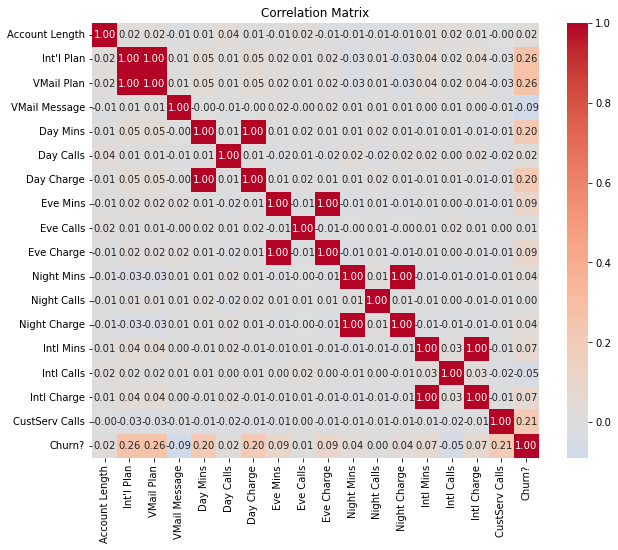

In [55]:
numeric_attributes = ['Account Length',"Int'l Plan","VMail Plan","VMail Message",
                    'Day Mins', 'Day Calls', 'Day Charge', 'Eve Mins', 
                    'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls', 'Night Charge', 
                    'Intl Mins', 'Intl Calls', 'Intl Charge', 'CustServ Calls']
correlation_matrix = df[numeric_attributes + ['Churn?']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Correlation Matrix')
plt.show()

In [56]:
# df.to_excel("Cleaned Data.xlsx",index=False)

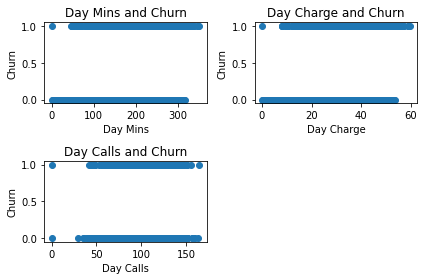

In [57]:
plt.subplot(2,2,1)
plt.scatter(df['Day Mins'],df['Churn?'])
plt.xlabel('Day Mins')
plt.ylabel('Churn')
plt.title('Day Mins and Churn')

plt.subplot(2,2,2)
plt.scatter(df['Day Charge'],df['Churn?'])
plt.xlabel('Day Charge')
plt.ylabel('Churn')
plt.title('Day Charge and Churn')

plt.subplot(2,2,3)
plt.scatter(df['Day Calls'],df['Churn?'])
plt.xlabel('Day Calls')
plt.ylabel('Churn')
plt.title('Day Calls and Churn')

plt.tight_layout()

<AxesSubplot:>

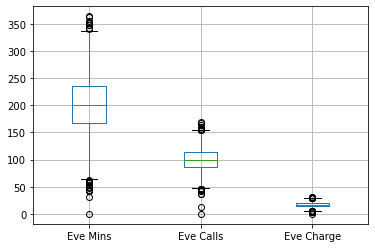

In [58]:
#Boxplot
df.boxplot(column=['Eve Mins','Eve Calls','Eve Charge'])

# Predictive Modeling

In [59]:
columns_to_drop=['State','Phone','Area Code']
df1=df.drop(columns=columns_to_drop)

In [60]:
x=df1.iloc[:,:-1]   #Input Variables
y=df1.iloc[:,-1]    #Output Variables

In [61]:
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import  accuracy_score, recall_score, precision_score, f1_score

In [62]:
# Splitting data into training and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=60)

In [63]:
#Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

dt_classifier = DecisionTreeClassifier()
dt_classifier.fit(x_train, y_train)

y_pred = dt_classifier.predict(x_test)

#Evaluating the model using various metrics
accuracy = accuracy_score(y_test, y_pred)

f1score = f1_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

print('Accuracy',accuracy)
print("F1 Score:", f1score)
print("Recall:", recall)
print("Precision:", precision)

Accuracy 0.9307228915662651
F1 Score: 0.7676767676767677
Recall: 0.7916666666666666
Precision: 0.7450980392156863


In [64]:
#Naive Bayes Classifier

from sklearn.naive_bayes import GaussianNB

nb_classifier = GaussianNB()
nb_classifier.fit(x_train, y_train)

y_pred = nb_classifier.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)

f1score = f1_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1score)
print("Recall:", recall)
print("Precision:", precision)

Accuracy: 0.8765060240963856
F1 Score: 0.511904761904762
Recall: 0.4479166666666667
Precision: 0.5972222222222222


In [65]:
#Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(x_train, y_train)

y_pred = rf_classifier.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)

f1score = f1_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1score)
print("Recall:", recall)
print("Precision:", precision)

Accuracy: 0.9593373493975904
F1 Score: 0.8421052631578947
Recall: 0.75
Precision: 0.96


### k-fold cross validation (k=3)

In [67]:
#Decision Tree Classifier

y_pred = cross_val_predict(dt_classifier, x, y, cv=3)

accuracy = accuracy_score(y, y_pred)

f1score = f1_score(y, y_pred)

recall = recall_score(y,y_pred)

precision = precision_score(y, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1score)
print("Recall:", recall)
print("Precision:", precision)

Accuracy: 0.9083509195055773
F1 Score: 0.6910569105691057
Recall: 0.7053941908713693
Precision: 0.6772908366533864


In [68]:
#Naive Bayes Classifier

y_pred = cross_val_predict(nb_classifier, x, y, cv=3)

accuracy = accuracy_score(y, y_pred)

f1score = f1_score(y, y_pred)

recall = recall_score(y,y_pred)

precision = precision_score(y, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1score)
print("Recall:", recall)
print("Precision:", precision)

Accuracy: 0.8540850165812481
F1 Score: 0.46696035242290745
Recall: 0.43983402489626555
Precision: 0.49765258215962443


In [69]:
#Random Forest Classifier

y_pred = cross_val_predict(rf_classifier, x, y, cv=3)

accuracy = accuracy_score(y, y_pred)

f1score = f1_score(y, y_pred)

recall = recall_score(y,y_pred)

precision = precision_score(y, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1score)
print("Recall:", recall)
print("Precision:", precision)

Accuracy: 0.9523665963219777
F1 Score: 0.8119047619047619
Recall: 0.7074688796680498
Precision: 0.952513966480447


### k-fold cross validation (k=10)

In [71]:
#Decision Tree Classifier

y_pred = cross_val_predict(dt_classifier, x, y, cv=10)

accuracy = accuracy_score(y, y_pred)

f1score = f1_score(y, y_pred)

recall = recall_score(y,y_pred)

precision = precision_score(y, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1score)
print("Recall:", recall)
print("Precision:", precision)

Accuracy: 0.9161893277057582
F1 Score: 0.7134020618556701
Recall: 0.7178423236514523
Precision: 0.7090163934426229


In [72]:
#Naive Bayes Classifier

y_pred = cross_val_predict(nb_classifier, x, y, cv=10)

accuracy = accuracy_score(y, y_pred)

f1score = f1_score(y, y_pred)

recall = recall_score(y,y_pred)

precision = precision_score(y, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1score)
print("Recall:", recall)
print("Precision:", precision)

Accuracy: 0.8531805848658426
F1 Score: 0.4630650496141125
Recall: 0.43568464730290457
Precision: 0.49411764705882355


In [73]:
#Random Forest Classifier

y_pred = cross_val_predict(rf_classifier, x, y, cv=10)

accuracy = accuracy_score(y, y_pred)

f1score = f1_score(y, y_pred)

recall = recall_score(y,y_pred)

precision = precision_score(y, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1score)
print("Recall:", recall)
print("Precision:", precision)

Accuracy: 0.9535725052758517
F1 Score: 0.8205128205128205
Recall: 0.7302904564315352
Precision: 0.9361702127659575


In [74]:
#Prediction using different models

Account_length=int(input("Enter account length: "))
Intl_plan=int(input("International Plan?(No:0/Yes:1) : "))
VMail_plan=int(input("VMail Plan?(No:0/Yes:1): "))
VMail_message=int(input("Enter no. of VMail messages: "))
Day_mins=float(input("Enter day mins: "))
Day_calls=int(input("Enter no. of Day calls: "))
Day_charge=float(input("Enter Day charge: "))
Eve_mins=float(input("Enter eve mins: "))
Eve_calls=int(input("Enter no. of eve calls: "))
Eve_charge=float(input("Enter eve charge: "))
Night_mins=float(input("Enter night mins: "))
Night_calls=int(input("Enter no. night calls: "))
Night_charge=float(input("Enter night charge: "))
Intl_mins=float(input("Enter international mins: "))
Intl_calls=int(input("Enter no. international calls: "))
Intl_charge=float(input("Enter international charge: "))
CustServ_calls=int(input("Enter no. of customer service calls: "))

input_data=np.array([[Account_length,Intl_plan,VMail_plan,VMail_message,Day_mins,Day_calls,Day_charge,Eve_mins,Eve_calls,Eve_charge,Night_mins,Night_calls,Night_charge,Intl_mins,Intl_calls, Intl_charge, CustServ_calls]])

predictedResult1=dt_classifier.predict(input_data)
predictedResult2=nb_classifier.predict(input_data)
predictedResult3=rf_classifier.predict(input_data)

print('--------------------')
print('Decision Tree Result:')
if predictedResult1==0:
    print("Churn: False")
else:
    print("Churn: True")
print('--------------------')
print('Naive Bayes Result: ')
if predictedResult2==0:
    print("Churn: False")
else:
    print("Churn: True")
print('--------------------')   
print('Random Forest Result: ')
if predictedResult3==0:
    print("Churn: False")
else:
    print("Churn: True")
print('--------------------')

Enter account length: 128
International Plan?(No:0/Yes:1) : 1
VMail Plan?(No:0/Yes:1): 1
Enter no. of VMail messages: 23
Enter day mins: 300
Enter no. of Day calls: 50
Enter Day charge: 1
Enter eve mins: 200
Enter no. of eve calls: 35
Enter eve charge: 1.3
Enter night mins: 100
Enter no. night calls: 10
Enter night charge: 1.5
Enter international mins: 30
Enter no. international calls: 3
Enter international charge: 1.8
Enter no. of customer service calls: 5
--------------------
Decision Tree Result:
Churn: True
--------------------
Naive Bayes Result: 
Churn: True
--------------------
Random Forest Result: 
Churn: True
--------------------


C:\Users\admi\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\admi\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
C:\Users\admi\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


| Split Method | Accuracy | F1score | Recall | Precision |
|:-----------------------:|:-------------------:|:-------------------:|:-----------------------:|:--------:|
| Simple Train Test splitting (Decision Tree)           | 0.9382530120481928   | 0.8121827411167514   | 0.7916666666666666     | 0.7835051546391752   |
| K-fold splitting k=10 (Decision Tree)             | 0.9201085318058486  | 0.7141361256544503   | 0.7261410788381742     | 0.7246376811594203   |
| K-fold splitting k=3 (Decision Tree)           | 0.9104612601748568   | 0.7004048582995951   | 0.7136929460580913     | 0.68389662027833   |
| Simple Train Test splitting (Naive Bayes)        | 0.8765060240963856   | 0.511904761904762   | 0.4479166666666667     | 0.5972222222222222   |
| K-fold splitting k=10 (Naive Bayes)        | 0.8531805848658426   | 0.4630650496141125   | 0.43568464730290457     | 0.49411764705882355   |
| K-fold splitting k=3 (Naive Bayes)           | 0.8540850165812481  | 0.46696035242290745   | 0.43983402489626555     | 0.49765258215962443   |
| Simple Train Test splitting (Random Forest)             | 0.9593373493975904  | 0.8421052631578947   | 0.75     | 0.96   |
| K-fold splitting k=10 (Random Forest)             | 0.9535725052758517  | 0.8205128205128205   | 0.7302904564315352     | 0.9361702127659575   |
| K-fold splitting k=3 (Random Forest)             | 0.9523665963219777  | 0.8119047619047619   | 0.7074688796680498    | 0.952513966480447   |